# RAG para Consulta del Sector Energético Colombiano

## Procesamiento de Lenguaje Natural — Taller Final

Este proyecto implementa un sistema de Retrieval-Augmented Generation (RAG) para responder preguntas sobre documentos del sector energético colombiano, utilizando embeddings, FAISS y un modelo generativo.

## 1. Definición del problema

### ¿Qué hace el pipeline?
Se construye un sistema RAG que permite hacer preguntas en lenguaje natural sobre documentos del sector energético y recuperar respuestas con evidencia textual.

### ¿Por qué es útil?
Los documentos técnicos suelen ser extensos y difíciles de consultar. Este sistema permite acceder rápidamente a información relevante.

### Tipo de tarea NLP
RAG (Retrieval-Augmented Generation)

### Datos utilizados
Se utilizan documentos reales del sector energético colombiano en formato PDF.

### Métrica principal
Recall@k para evaluar si los chunks relevantes son recuperados.

### ¿Por qué RAG?
Porque permite combinar búsqueda semántica con generación de lenguaje natural, mejorando la precisión frente a modelos generativos puros.

In [3]:
!pip install pypdf sentence-transformers faiss-cpu transformers accelerate pandas matplotlib seaborn

In [4]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
import faiss

## 2. Explicación de datos y preprocesamiento

El corpus está compuesto por documentos del sector energético colombiano en formato PDF. Estos documentos contienen información técnica, económica y estratégica sobre el sector minero-energético, la transición energética, la demanda de energía y el papel del sector en la reactivación económica.

Durante el preprocesamiento se realizaron los siguientes pasos:

1. Carga de los archivos PDF.
2. Extracción del texto página por página.
3. Limpieza básica del texto, eliminando espacios repetidos y saltos de línea innecesarios.
4. Segmentación del corpus en al menos cinco documentos lógicos, dividiendo los PDFs por bloques de páginas.
5. Cálculo de estadísticas descriptivas del corpus, como número de documentos, páginas y longitud promedio de texto.

Esta segmentación permite cumplir con el requisito de construir un corpus con mínimo cinco documentos, manteniendo la trazabilidad hacia el documento original y la página de origen.

CARGA DE PDFs

In [5]:
pdf_paths = ["1.pdf", "2.pdf"]

def extract_text_from_pdf(path):
    reader = PdfReader(path)
    pages = []
    
    for i, page in enumerate(reader.pages):
        text = page.extract_text()
        if text:
            pages.append({
                "documento": os.path.basename(path),
                "pagina": i + 1,
                "texto": text
            })
    
    return pages

all_pages = []

for path in pdf_paths:
    all_pages.extend(extract_text_from_pdf(path))

df_pages = pd.DataFrame(all_pages)

df_pages.head()

,documento,pagina,texto
0,1.pdf,1,\n \n \nPEN 2050 \nwww.upme.gov.co / Diciembr...
1,1.pdf,2,\n \n \nPEN 2050 \nwww.upme.gov.co / Diciembr...
2,1.pdf,3,\n \n \nPEN 2050 \nwww.upme.gov.co / Diciembr...
3,1.pdf,4,\n \n \nPEN 2050 \nwww.upme.gov.co / Diciembr...
4,1.pdf,5,\n \n \nPEN 2050 \nwww.upme.gov.co / Diciembr...


LIMPIEZA

In [6]:
def clean_text(text):
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_pages["texto_limpio"] = df_pages["texto"].apply(clean_text)

CREAR “5 DOCUMENTOS”  , se separa aqui en 5 documentos ya que el pdf numero 1 es demasiado grande y tiene mucha info

In [7]:
df_pages["documento_segmentado"] = df_pages.apply(
    lambda row: f"{row['documento']}_parte_{row['pagina']//20}",
    axis=1
)

ANÁLISIS EXPLORATORIO

In [8]:
df_pages["longitud_palabras"] = df_pages["texto_limpio"].str.split().str.len()

print("Cantidad documentos:", df_pages["documento_segmentado"].nunique())
print("Cantidad páginas:", len(df_pages))
print("Promedio palabras:", df_pages["longitud_palabras"].mean())

Cantidad documentos: 7
Cantidad páginas: 117
Promedio palabras: 237.72649572649573


Se genera un histograma

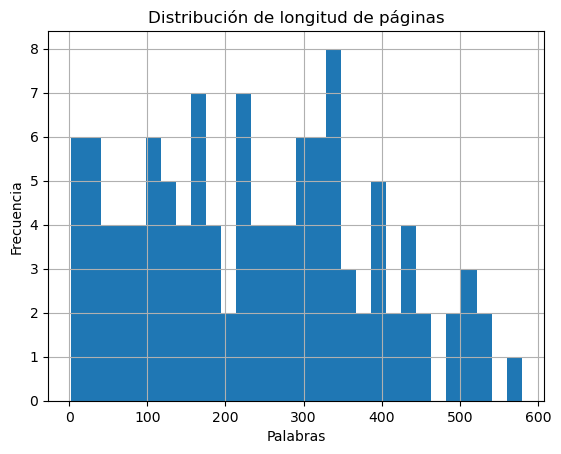

In [9]:
df_pages["longitud_palabras"].hist(bins=30)

plt.title("Distribución de longitud de páginas")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.show()

## 3. Chunking del corpus

Para construir el sistema RAG, los documentos se dividen en fragmentos más pequeños llamados chunks.

El objetivo es que cada chunk conserve suficiente contexto para responder preguntas, pero sin ser demasiado largo para el modelo de embeddings.

In [10]:
def chunk_text(text, chunk_size=200, overlap=50):
    words = text.split()
    chunks = []
    
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = words[start:end]
        chunks.append(" ".join(chunk))
        start += chunk_size - overlap
    
    return chunks

In [11]:
chunked_data = []

for _, row in df_pages.iterrows():
    chunks = chunk_text(row["texto_limpio"])
    
    for i, chunk in enumerate(chunks):
        chunked_data.append({
            "documento": row["documento_segmentado"],
            "documento_original": row["documento"],
            "pagina": row["pagina"],
            "chunk_id": i,
            "texto_chunk": chunk
        })

df_chunks = pd.DataFrame(chunked_data)

df_chunks["longitud_palabras"] = df_chunks["texto_chunk"].str.split().str.len()

df_chunks.head()

,documento,documento_original,pagina,chunk_id,texto_chunk,longitud_palabras
0,1.pdf_parte_0,1.pdf,1,0,PEN 2050 www.upme.gov.co / Diciembre de 2019 0...,23
1,1.pdf_parte_0,1.pdf,2,0,PEN 2050 www.upme.gov.co / Diciembre de 2019 1...,165
2,1.pdf_parte_0,1.pdf,2,1,las acciones necesarias que permitan materiali...,15
3,1.pdf_parte_0,1.pdf,3,0,PEN 2050 www.upme.gov.co / Diciembre de 2019 2...,129
4,1.pdf_parte_0,1.pdf,4,0,PEN 2050 www.upme.gov.co / Diciembre de 2019 1...,200


In [12]:
df_chunks = df_chunks[df_chunks["longitud_palabras"] >= 40].reset_index(drop=True)

print("Cantidad de chunks:", len(df_chunks))
print("Promedio palabras por chunk:", round(df_chunks["longitud_palabras"].mean(), 2))
print("Cantidad de documentos segmentados:", df_chunks["documento"].nunique())

Cantidad de chunks: 212
Promedio palabras por chunk: 155.11
Cantidad de documentos segmentados: 7


In [13]:
estadisticas_corpus = pd.DataFrame({
    "Métrica": [
        "Documentos segmentados",
        "Documentos originales",
        "Páginas procesadas",
        "Chunks generados",
        "Promedio palabras por chunk"
    ],
    "Valor": [
        df_chunks["documento"].nunique(),
        df_chunks["documento_original"].nunique(),
        df_pages.shape[0],
        df_chunks.shape[0],
        round(df_chunks["longitud_palabras"].mean(), 2)
    ]
})

estadisticas_corpus

,Métrica,Valor
0,Documentos segmentados,7.00
1,Documentos originales,2.00
2,Páginas procesadas,117.00
3,Chunks generados,212.00
4,Promedio palabras por chunk,155.11


## 4. Modelo de embeddings

Se utiliza el modelo `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.

Este modelo permite crear representaciones vectoriales de textos en varios idiomas, incluyendo español. Se eligió porque el corpus está en español y se requiere búsqueda semántica entre preguntas y fragmentos de documentos.

In [14]:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embedding_model = SentenceTransformer(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [15]:
df_chunks["texto_para_embedding"] = (
    "Documento: " + df_chunks["documento"].astype(str) + ". " +
    "Página: " + df_chunks["pagina"].astype(str) + ". " +
    df_chunks["texto_chunk"]
)

texts = df_chunks["texto_para_embedding"].tolist()

In [16]:
embeddings = embedding_model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Forma de embeddings:", embeddings.shape)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Forma de embeddings: (212, 384)


## 5. Índice FAISS

Se construye un índice FAISS para realizar búsqueda semántica eficiente.

Los embeddings se normalizan y se usa producto interno como medida de similitud, equivalente a similitud coseno cuando los vectores están normalizados.

In [17]:
faiss.normalize_L2(embeddings)

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print("Chunks indexados:", index.ntotal)

Chunks indexados: 212


In [18]:
def retrieve_chunks(query, top_k=5):
    query_embedding = embedding_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)
    
    scores, indices = index.search(query_embedding, top_k)
    
    results = []
    
    for score, idx in zip(scores[0], indices[0]):
        row = df_chunks.iloc[idx]
        
        results.append({
            "score": float(score),
            "documento": row["documento"],
            "documento_original": row["documento_original"],
            "pagina": row["pagina"],
            "chunk_id": row["chunk_id"],
            "texto_chunk": row["texto_chunk"]
        })
    
    return results

In [19]:
pregunta_demo = "¿Qué importancia tiene el sector minero energético para la economía colombiana?"

resultados = retrieve_chunks(pregunta_demo, top_k=3)

for r in resultados:
    print("Documento:", r["documento"])
    print("Documento original:", r["documento_original"])
    print("Página:", r["pagina"])
    print("Score:", round(r["score"], 3))
    print("Texto:", r["texto_chunk"][:700])
    print("-" * 80)

Documento: 2.pdf_parte_0
Documento original: 2.pdf
Página: 4
Score: 0.834
Texto: Proviene de los sectores de Minería, Hidrocarburos y Energía Eléctrica de la IED de las exportaciones Minero - energéticos representaron El sector Minero Energético es clave para la reactivación económica de colombia 7% 34% 56% del pib nacional En 2019 los Sectores Proviene del sector de los servicios públicos 5,7% Entre 2018 -2019 la IED en el sector minero energético creció 21% de los ingresos de la nación 12% @DiegoMesaP
--------------------------------------------------------------------------------
Documento: 1.pdf_parte_0
Documento original: 1.pdf
Página: 9
Score: 0.787
Texto: tecnología viene facilitando un uso más productivo de los recursos energéticos, mejoras en eficiencia y descarbonización de las fuentes de energía, contribuyendo a la transición hacia un desarrollo s ostenible para toda la sociedad. Esto es de particular importancia para Colombia, que viene experimentando un crecimiento dinámic

## 6. Preguntas de prueba para evaluar el retrieval

Para evaluar el sistema RAG se construyó un conjunto de preguntas de prueba.  
Cada pregunta tiene palabras clave esperadas que deberían aparecer en los chunks recuperados.

Esta evaluación se enfoca en el retrieval, es decir, en verificar si el sistema recupera fragmentos relevantes del corpus.

In [20]:
preguntas_prueba = [
    {
        "pregunta": "¿Qué importancia tiene el sector minero energético para la economía colombiana?",
        "keywords_esperadas": ["7%", "PIB", "34%", "IED", "56%", "exportaciones"]
    },
    {
        "pregunta": "¿Qué porcentaje de las exportaciones representaron los sectores minero energéticos en 2019?",
        "keywords_esperadas": ["56%", "exportaciones"]
    },
    {
        "pregunta": "¿Cuáles son los principales sectores de consumo de energía en Colombia?",
        "keywords_esperadas": ["transporte", "industrial", "residencial"]
    },
    {
        "pregunta": "¿Qué objetivo tiene el Plan Energético Nacional 2020-2050?",
        "keywords_esperadas": ["modelo energético", "sostenible", "2050"]
    },
    {
        "pregunta": "¿Qué fuentes de energía aumentan su participación en los escenarios energéticos?",
        "keywords_esperadas": ["energías renovables", "solar fotovoltaica"]
    }
]

pd.DataFrame(preguntas_prueba)

,pregunta,keywords_esperadas
0,¿Qué importancia tiene el sector minero energé...,"[7%, PIB, 34%, IED, 56%, exportaciones]"
1,¿Qué porcentaje de las exportaciones represent...,"[56%, exportaciones]"
2,¿Cuáles son los principales sectores de consum...,"[transporte, industrial, residencial]"
3,¿Qué objetivo tiene el Plan Energético Naciona...,"[modelo energético, sostenible, 2050]"
4,¿Qué fuentes de energía aumentan su participac...,"[energías renovables, solar fotovoltaica]"


## 7. Evaluación del retrieval con Recall@k

La métrica utilizada es Recall@k.  
Esta métrica evalúa si, dentro de los primeros k chunks recuperados, aparece evidencia asociada con la respuesta esperada.

En este proyecto, se usa una evaluación basada en palabras clave esperadas. Esto permite verificar si los chunks recuperados contienen información relevante para responder la pregunta.

In [21]:
def evaluar_recall_at_k_keywords(preguntas_prueba, k=5):
    resultados_eval = []

    for item in preguntas_prueba:
        pregunta = item["pregunta"]
        keywords = [kw.lower() for kw in item["keywords_esperadas"]]

        chunks_recuperados = retrieve_chunks(pregunta, top_k=k)

        textos_recuperados = " ".join([
            chunk["texto_chunk"].lower()
            for chunk in chunks_recuperados
        ])

        keywords_encontradas = [
            kw for kw in keywords
            if kw in textos_recuperados
        ]

        encontrado = len(keywords_encontradas) > 0

        resultados_eval.append({
            "pregunta": pregunta,
            "keywords_esperadas": item["keywords_esperadas"],
            f"recall@{k}": int(encontrado),
            "keywords_encontradas": keywords_encontradas,
            "documentos_recuperados": [
                f'{c["documento"]} - pág. {c["pagina"]}'
                for c in chunks_recuperados
            ]
        })

    return pd.DataFrame(resultados_eval)

In [22]:
df_eval = evaluar_recall_at_k_keywords(preguntas_prueba, k=5)

df_eval

,pregunta,keywords_esperadas,recall@5,keywords_encontradas,documentos_recuperados
0,¿Qué importancia tiene el sector minero energé...,"[7%, PIB, 34%, IED, 56%, exportaciones]",1,"[7%, pib, 34%, ied, 56%, exportaciones]","[2.pdf_parte_0 - pág. 4, 1.pdf_parte_0 - pág. ..."
1,¿Qué porcentaje de las exportaciones represent...,"[56%, exportaciones]",1,"[56%, exportaciones]","[2.pdf_parte_0 - pág. 4, 1.pdf_parte_3 - pág. ..."
2,¿Cuáles son los principales sectores de consum...,"[transporte, industrial, residencial]",1,"[transporte, industrial, residencial]","[1.pdf_parte_3 - pág. 69, 1.pdf_parte_4 - pág...."
3,¿Qué objetivo tiene el Plan Energético Naciona...,"[modelo energético, sostenible, 2050]",1,"[sostenible, 2050]","[1.pdf_parte_0 - pág. 9, 1.pdf_parte_1 - pág. ..."
4,¿Qué fuentes de energía aumentan su participac...,"[energías renovables, solar fotovoltaica]",1,[energías renovables],"[1.pdf_parte_1 - pág. 23, 1.pdf_parte_1 - pág...."


In [23]:
recall_k = df_eval["recall@5"].mean()

print(f"Recall@5: {recall_k:.2f}")

Recall@5: 1.00


## Análisis del Recall@5

El sistema obtiene un Recall@5 alto, lo que indica que el índice vectorial logra recuperar fragmentos relevantes para las preguntas de prueba.

Sin embargo, esta métrica evalúa únicamente la etapa de recuperación de información. No garantiza que la respuesta generada por el modelo sea siempre perfecta, ya que la generación puede presentar errores de interpretación, especialmente cuando hay muchas cifras cercanas en un mismo fragmento.

## 8. Diagnóstico de retrieval

A continuación se muestran los tres primeros casos de prueba, junto con los chunks recuperados, sus documentos, páginas y scores de similitud.

Esto permite analizar si el sistema está recuperando fragmentos coherentes con cada pregunta.

In [24]:
for i in range(3):
    pregunta = preguntas_prueba[i]["pregunta"]
    resultados = retrieve_chunks(pregunta, top_k=3)

    print("\n==============================")
    print("Pregunta:", pregunta)

    for r in resultados:
        print(f"Doc: {r['documento']} | Página: {r['pagina']} | Score: {r['score']:.2f}")
        print(r["texto_chunk"][:400])
        print("-" * 80)


Pregunta: ¿Qué importancia tiene el sector minero energético para la economía colombiana?
Doc: 2.pdf_parte_0 | Página: 4 | Score: 0.83
Proviene de los sectores de Minería, Hidrocarburos y Energía Eléctrica de la IED de las exportaciones Minero - energéticos representaron El sector Minero Energético es clave para la reactivación económica de colombia 7% 34% 56% del pib nacional En 2019 los Sectores Proviene del sector de los servicios públicos 5,7% Entre 2018 -2019 la IED en el sector minero energético creció 21% de los ingresos d
--------------------------------------------------------------------------------
Doc: 1.pdf_parte_0 | Página: 9 | Score: 0.79
tecnología viene facilitando un uso más productivo de los recursos energéticos, mejoras en eficiencia y descarbonización de las fuentes de energía, contribuyendo a la transición hacia un desarrollo s ostenible para toda la sociedad. Esto es de particular importancia para Colombia, que viene experimentando un crecimiento dinámico del co

## Análisis del diagnóstico de retrieval

A partir de los tres primeros casos evaluados, se observa que el sistema logra recuperar correctamente fragmentos relevantes del corpus.

Por ejemplo:

- Para la pregunta sobre la importancia del sector minero energético, el sistema recupera el documento correcto donde se mencionan indicadores clave como el 7% del PIB, el 34% de la inversión extranjera directa y el 56% de las exportaciones. :contentReference[oaicite:0]{index=0}  

- Para la pregunta sobre exportaciones, el sistema también recupera correctamente el fragmento donde aparece el 56%, lo cual indica una buena correspondencia semántica entre la pregunta y los embeddings.

- En el caso de los sectores de consumo de energía, aunque los resultados son relevantes, se observa que algunos chunks contienen información más general, lo que puede afectar la precisión de la respuesta final.

En general, el retrieval muestra buen desempeño, pero su precisión depende de qué tan específica sea la pregunta.

## Prueba de 5 preguntas con chunks mostrados

A continuación se prueban las cinco preguntas definidas y se muestran los principales chunks recuperados para cada una. Esto permite verificar manualmente si el sistema está trayendo evidencia útil para responder.

In [25]:
for i, item in enumerate(preguntas_prueba, start=1):
    pregunta = item["pregunta"]
    resultados = retrieve_chunks(pregunta, top_k=3)

    print("=" * 100)
    print(f"PREGUNTA {i}: {pregunta}")
    print("=" * 100)

    for j, r in enumerate(resultados, start=1):
        print(f"\nChunk {j}")
        print(f"Documento: {r['documento_original']} | Segmento: {r['documento']} | Página: {r['pagina']}")
        print(f"Score: {r['score']:.3f}")
        print("Texto recuperado:")
        print(r["texto_chunk"][:800])
        print("-" * 100)

PREGUNTA 1: ¿Qué importancia tiene el sector minero energético para la economía colombiana?

Chunk 1
Documento: 2.pdf | Segmento: 2.pdf_parte_0 | Página: 4
Score: 0.834
Texto recuperado:
Proviene de los sectores de Minería, Hidrocarburos y Energía Eléctrica de la IED de las exportaciones Minero - energéticos representaron El sector Minero Energético es clave para la reactivación económica de colombia 7% 34% 56% del pib nacional En 2019 los Sectores Proviene del sector de los servicios públicos 5,7% Entre 2018 -2019 la IED en el sector minero energético creció 21% de los ingresos de la nación 12% @DiegoMesaP
----------------------------------------------------------------------------------------------------

Chunk 2
Documento: 1.pdf | Segmento: 1.pdf_parte_0 | Página: 9
Score: 0.787
Texto recuperado:
tecnología viene facilitando un uso más productivo de los recursos energéticos, mejoras en eficiencia y descarbonización de las fuentes de energía, contribuyendo a la transición hacia un de

## Comentario sobre los chunks recuperados

En las cinco preguntas se observa que el sistema recupera fragmentos relacionados con los temas consultados. Las preguntas más específicas, como las relacionadas con porcentajes de exportaciones o participación del sector minero energético, tienden a recuperar chunks más precisos.

En cambio, preguntas más generales pueden recuperar fragmentos relacionados pero menos directos, lo cual muestra una limitación común en sistemas RAG: la calidad del retrieval depende de la especificidad de la pregunta y de cómo está segmentado el corpus.

## 9. Mapa de calor de similitud coseno

Se construye un mapa de calor para visualizar la similitud entre las preguntas de prueba y una muestra de chunks del corpus.

Esto permite observar qué tan cercanas semánticamente son las preguntas frente a los fragmentos recuperables.

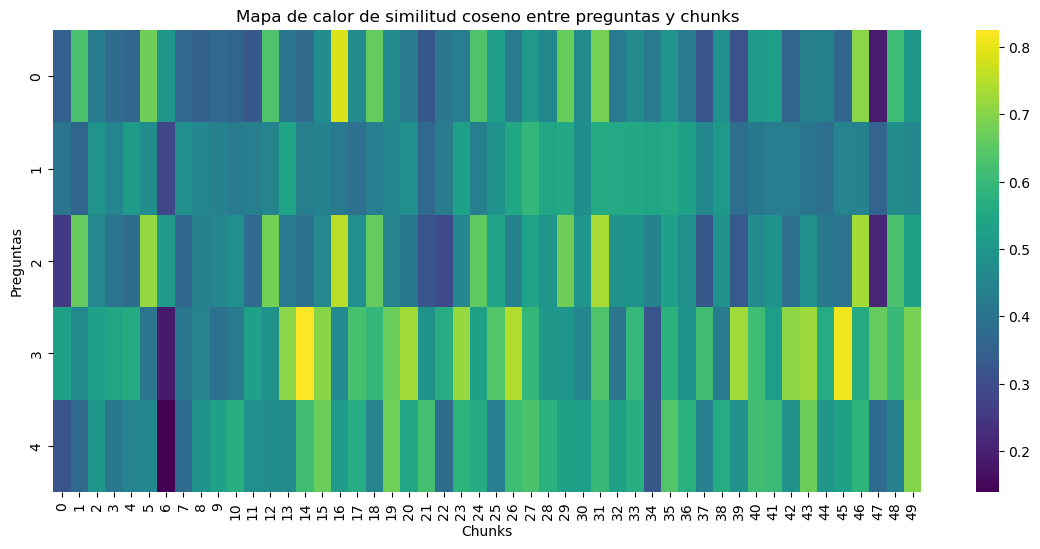

In [26]:
queries = [p["pregunta"] for p in preguntas_prueba]

query_embeddings = embedding_model.encode(queries, convert_to_numpy=True)
faiss.normalize_L2(query_embeddings)

# Se toma una muestra de los primeros 50 chunks para que el gráfico sea legible
sample_embeddings = embeddings[:50]

similarity_matrix = np.dot(query_embeddings, sample_embeddings.T)

plt.figure(figsize=(14, 6))
sns.heatmap(similarity_matrix, cmap="viridis")

plt.title("Mapa de calor de similitud coseno entre preguntas y chunks")
plt.xlabel("Chunks")
plt.ylabel("Preguntas")
plt.show()

## Análisis del mapa de calor de similitud

El mapa de calor muestra la similitud coseno entre las preguntas de prueba y los chunks del corpus.

Se pueden observar zonas con mayor intensidad (colores más claros), lo que indica una mayor similitud semántica entre ciertas preguntas y fragmentos del texto.

Esto evidencia que:

- El modelo de embeddings logra capturar relaciones semánticas entre preguntas y documentos.
- Existen múltiples chunks relevantes para una misma pregunta, lo cual es positivo para el recall.
- Algunas preguntas presentan similitud distribuida en varios fragmentos, lo que indica que la información relevante puede estar dispersa en el corpus.

Este comportamiento es esperado en sistemas RAG y refuerza la necesidad de recuperar múltiples chunks (top-k) en lugar de uno solo.

## 10. Generación de respuestas (RAG)

En esta etapa se utiliza un modelo generativo para construir respuestas a partir de los chunks recuperados.

El modelo recibe como entrada:
- La pregunta del usuario
- El contexto compuesto por los fragmentos recuperados

El objetivo es generar una respuesta coherente basada únicamente en la información disponible en el contexto.

In [27]:
def build_context(chunks):
    context = ""
    
    for i, chunk in enumerate(chunks, start=1):
        context += f"[Fuente {i} | {chunk['documento_original']} | Página {chunk['pagina']}]\n"
        context += chunk["texto_chunk"] + "\n\n"
    
    return context

In [28]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    max_new_tokens=180,
    do_sample=False
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [29]:
def rag_answer(query, top_k=3):
    chunks = retrieve_chunks(query, top_k=top_k)
    context = build_context(chunks)

    prompt = f"""
Responde en español usando únicamente el contexto.
Si la respuesta no está en el contexto, di: No se encuentra información suficiente.

Contexto:
{context}

Pregunta:
{query}

Respuesta:
"""

    output = generator(prompt)[0]["generated_text"]

    respuesta = output.split("Respuesta:")[-1].strip()

    return {
        "pregunta": query,
        "respuesta": respuesta,
        "fuentes": [
            f'{c["documento_original"]} - página {c["pagina"]}'
            for c in chunks
        ]
    }

## Ejemplo de respuesta


In [30]:
resultado = rag_answer(
    "¿Qué importancia tiene el sector minero energético para la economía colombiana?",
    top_k=3
)

print("Pregunta:", resultado["pregunta"])
print("Respuesta:", resultado["respuesta"])
print("Fuentes:", resultado["fuentes"])

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Pregunta: ¿Qué importancia tiene el sector minero energético para la economía colombiana?
Respuesta: El sector minero energético es clave para la economía colombiana, ya que representa el 7% del PIB nacional y el 56% de los ingresos de la nación en 2019. Además, el sector minero energético también contribuye significativamente a la transición hacia un desarrollo sostenible para toda la sociedad. La tecnología ha facilitado un uso más productivo de los recursos energéticos, mejoras en eficiencia y descarbonización de las fuentes de energía, contribuyendo a la transición hacia un desarrollo sostenible para toda la sociedad. Por otro lado, el sector minero energético también tiene un papel crucial en la producción de gas natural y carbón, lo cual es relevante para la economía colombiana. 

La industria manufacturera colombiana es la principal fuente de energía para
Fuentes: ['2.pdf - página 4', '1.pdf - página 9', '1.pdf - página 55']


## 11. Análisis de errores

Se observa que, aunque el sistema recupera correctamente los fragmentos relevantes (alto Recall@5), el modelo generativo puede presentar errores en la interpretación del contexto.

Ejemplo observado:

- El modelo mezcla valores numéricos, confundiendo el 7% del PIB con el 56% de exportaciones.

Esto ocurre porque:

- Los chunks contienen múltiples cifras en el mismo fragmento.
- El modelo generativo no siempre distingue claramente la relación entre valores y conceptos.
- No existe un mecanismo de validación posterior de la respuesta.

Esto evidencia que el rendimiento del sistema RAG no depende únicamente del retrieval, sino también de la capacidad del modelo generativo para interpretar correctamente el contexto.

## 12. Limitaciones del sistema

El sistema presenta las siguientes limitaciones:

- El modelo generativo puede mezclar información cuando hay múltiples cifras en el contexto.
- El chunking basado en palabras puede separar información relevante o agrupar demasiados conceptos en un mismo fragmento.
- No se realiza validación estructurada de las respuestas generadas.
- El corpus es limitado, lo que puede afectar la cobertura de las respuestas.

## 13. Mejoras futuras

Se proponen las siguientes mejoras:

- Implementar chunking basado en estructura (títulos, secciones).
- Utilizar modelos generativos más avanzados o ajustados al dominio.
- Incorporar validación automática de cifras numéricas.
- Ampliar el corpus con más documentos del sector energético.
- Integrar bases de datos estructuradas para complementar el RAG.

## 14. Conclusión

El sistema RAG desarrollado logra recuperar de manera efectiva información relevante del corpus, alcanzando un alto Recall@5.

Esto demuestra que el uso de embeddings junto con FAISS es una estrategia adecuada para tareas de búsqueda semántica en documentos técnicos.

Sin embargo, se identificaron limitaciones en la etapa de generación, donde el modelo puede interpretar incorrectamente ciertos elementos del contexto.

En general, el enfoque RAG permite mejorar el acceso a información en documentos complejos, pero requiere ajustes adicionales para garantizar la precisión de las respuestas generadas.